<a href="https://colab.research.google.com/github/GuFerreiraV/notebooks_google_colab/blob/main/VCT_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução
Análise de dados e aplicação de modelos de regressão, referente ao conjuntos de dados do **VCT 2025 Paris - Valorant**

# Objetivo
O dataset utilizado neste projeto possui conjuntos de dados referente aos agentes mais pickados, mapas mais jogados e estatísticas dos times e jogadores no último VCT 2025 que ocorreu em Paris. A ideia deste projeto é ter uma previsão de qual será o time mais perfomática no próximo VCT e para alcançar este objetivo trataremos de outliers, exploraremos os dados obtidos e usaremos técnicas de regressão (**Árvore de Decisão**, **KNN** e **Regressão Logística**)
para ter uma previsão.

---

Fonte: [kaggle](https://www.kaggle.com/datasets/piyush86kumarvalorant-champions-tour-2025-paris/data)

# **Desenvolvimento**

### **Importação de bibliotecas**

In [ ]:
import kagglehub as khub
from kagglehub import KaggleDatasetAdapter


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

### **Download de dataframe**

In [ ]:
path = khub.dataset_download("piyush86kumar/valorant-champions-tour-2025-paris")
print("Caminho dos datasets", path)

100%|██████████| 57.7k/57.7k [00:00<00:00, 24.3MB/s]

Extracting files...
Caminho dos datasets /root/.cache/kagglehub/datasets/piyush86kumar/valorant-champions-tour-2025-paris/versions/3


### **Carregando dados**

In [ ]:
agents_stats = pd.read_csv(path + "/agents_stats.csv")
maps_stats = pd.read_csv(path + "/maps_stats.csv")
matches = pd.read_csv(path + "/matches.csv")
player_stats = pd.read_csv(path + "/player_stats.csv")
economy_data = pd.read_csv(path + "/economy_data.csv")
detailed_matches_player_stats = pd.read_csv(path + "/detailed_matches_player_stats.csv")
detailed_matches_maps = pd.read_csv(path + "/detailed_matches_maps.csv")

datasets = {
    "Estatística de agentes": agents_stats,
    "Estatística dos mapas": maps_stats,
    "Estatística Por Jogador": player_stats,
    "Estatística de partidas": matches,
    "Estatística detalhada de partidas por jogador": detailed_matches_player_stats,
    "Estatística detalhada de partidas por mapa": detailed_matches_maps,
    "Dados Econômicos": economy_data
}

for name, df in datasets.items():
  print(f"--- {name} ---")
  display(df.head())
  # df.info()
  print("\n")

--- Estatística de agentes ---


,agent_name,total_utilization,Lotus,Abyss,Corrode,Ascent,Bind,Sunset,Haven
0,Omen,80.0,100.0,68.0,85.0,100.0,0.0,100.0,100.0
1,Sova,53.0,0.0,100.0,35.0,100.0,0.0,73.0,95.0
2,Yoru,53.0,56.0,50.0,46.0,68.0,77.0,41.0,30.0
3,Viper,43.0,47.0,0.0,77.0,0.0,95.0,23.0,65.0
4,Fade,43.0,94.0,0.0,65.0,0.0,77.0,27.0,5.0




--- Estatística dos mapas ---


,map_name,times_played,attack_win_percent,defense_win_percent
0,Lotus,18,51%,49%
1,Abyss,14,58%,42%
2,Corrode,13,53%,47%
3,Ascent,11,50%,50%
4,Bind,11,46%,54%




--- Estatística Por Jogador ---


...

,match_id,event_name,event_stage,match_date,team1,team2,score_overall,player_name,player_id,player_team,...,a,kd_diff,kast,adr,hs_percent,fk,fd,fk_fd_diff,map_name,map_winner
10,542195,Valorant Champions 2025,Group Stage: \n\t\t\t\t\t\tOpening (A),2025-09-12 09:00:00,Paper Rex,Xi Lai Gaming,2 - 0,something,17086,Paper Rex,...,12,9,91%,167,15%,4,0,4,Bind,Paper Rex
11,542195,Valorant Champions 2025,Group Stage: \n\t\t\t\t\t\tOpening (A),2025-09-12 09:00:00,Paper Rex,Xi Lai Gaming,2 - 0,Jinggg,7378,Paper Rex,...,7,10,82%,207,18%,5,2,3,Bind,Paper Rex
12,542195,Valorant Champions 2025,Group Stage: \n\t\t\t\t\t\tOpening (A),2025-09-12 09:00:00,Paper Rex,Xi Lai Gaming,2 - 0,f0rsakeN,9801,Paper Rex,...,13,5,77%,150,36%,2,5,-3,Bind,Paper Rex
13,542195,Valorant Champions 2025,Group Stage: \n\t\t\t\t\t\tOpening (A),2025-09-12 09:00:00,Paper Rex,Xi Lai Gaming,2 - 0,d4v41,9803,Paper Rex,...,5,0,82%,129,21%,1,1,0,Bind,Paper Rex
14,542195,Valorant Champions 2025,Group Stage: \n\t\t\t\t\t\tOpening (A),2025-09-12 09:00:00,Paper Rex,Xi Lai Gaming,2 - 0,PatMen,13744,Paper Rex,...,5,-1,68%,110,34%,0,2,-2,Bind,Paper Rex




--- Estatística detalhada de partidas por mapa ---


,match_id,map_name,map_order,score,winner,duration,picked_by
0,542195,Bind,1,13 - 9,Paper Rex,48:56,Xi Lai Gaming
1,542195,Sunset,2,13 - 5,Paper Rex,39:04,Paper Rex
2,542196,Corrode,1,6 - 13,Sentinels,41:17,Sentinels
3,542196,Sunset,2,13 - 4,GIANTX,38:15,GIANTX
4,542196,Haven,3,13 - 9,GIANTX,51:34,Decider




--- Dados Econômicos ---


,map,Team,Pistol Won,Eco (won),Semi-eco (won),Semi-buy (won),Full buy(won),match_id
0,Bind,PRX,1,4 (2),0 (0),3 (2),15 (9),542195
1,Bind,XLG,1,3 (1),1 (0),8 (3),10 (5),542195
2,Sunset,PRX,2,2 (2),1 (0),5 (4),10 (7),542195
3,Sunset,XLG,0,4 (0),2 (0),3 (0),9 (5),542195
4,All Maps,PRX,3,6 (4),1 (0),8 (6),25 (16),542195


#### **Tratando dados faltantes**

In [ ]:
for name, df in datasets.items():
    print(f"--- Missing values in {name} ---")
    print(df.isnull().sum())
    print("\n")

--- Missing values in Estatística de agentes ---
agent_name           0
total_utilization    0
Lotus                0
Abyss                0
Corrode              0
Ascent               0
Bind                 0
Sunset               0
Haven                0
dtype: int64


--- Missing values in Estatística dos mapas ---
map_name               0
times_played           0
attack_win_percent     0
defense_win_percent    0
dtype: int64


--- Missing values in Estatística Por Jogador ---
player          0
player_name     0
team            0
player_id       0
agents          0
agents_count    0
rounds          0
rating          0
acs             0
kd_ratio        0
kast            0
adr             0
kpr             0
apr             0
fkpr            0
fdpr            0
hs_percent      0
cl_percent      0
clutches        0
k_max           0
kills           0
deaths          0
assists         0
first_kills     0
first_deaths    0
dtype: int64


--- Missing values in Estatística de partidas ---
d

In [ ]:
# Remova as linhas com dados faltantes
detailed_matches_player_stats_cleaned = detailed_matches_player_stats.dropna()

print("Dimensão Original:", detailed_matches_player_stats.shape)
print("Dimensão depois de remover os NaN:", detailed_matches_player_stats_cleaned.shape)

datasets["Estatística detalhada de partidas por jogador"] = detailed_matches_player_stats.dropna()
detailed_matches_player_stats_cleaned = datasets["Estatística detalhada de partidas por jogador"]

for name, df in datasets.items():
    print(f"--- Missing values in {name} ---")
    print(df.isnull().sum())
    print("\n")

Dimensão Original: (1220, 26)
Dimensão depois de remover os NaN: (880, 26)


### **Explorando dados**

- Criando boxplots em todos os dataframes com features númericas, em busca de outliers

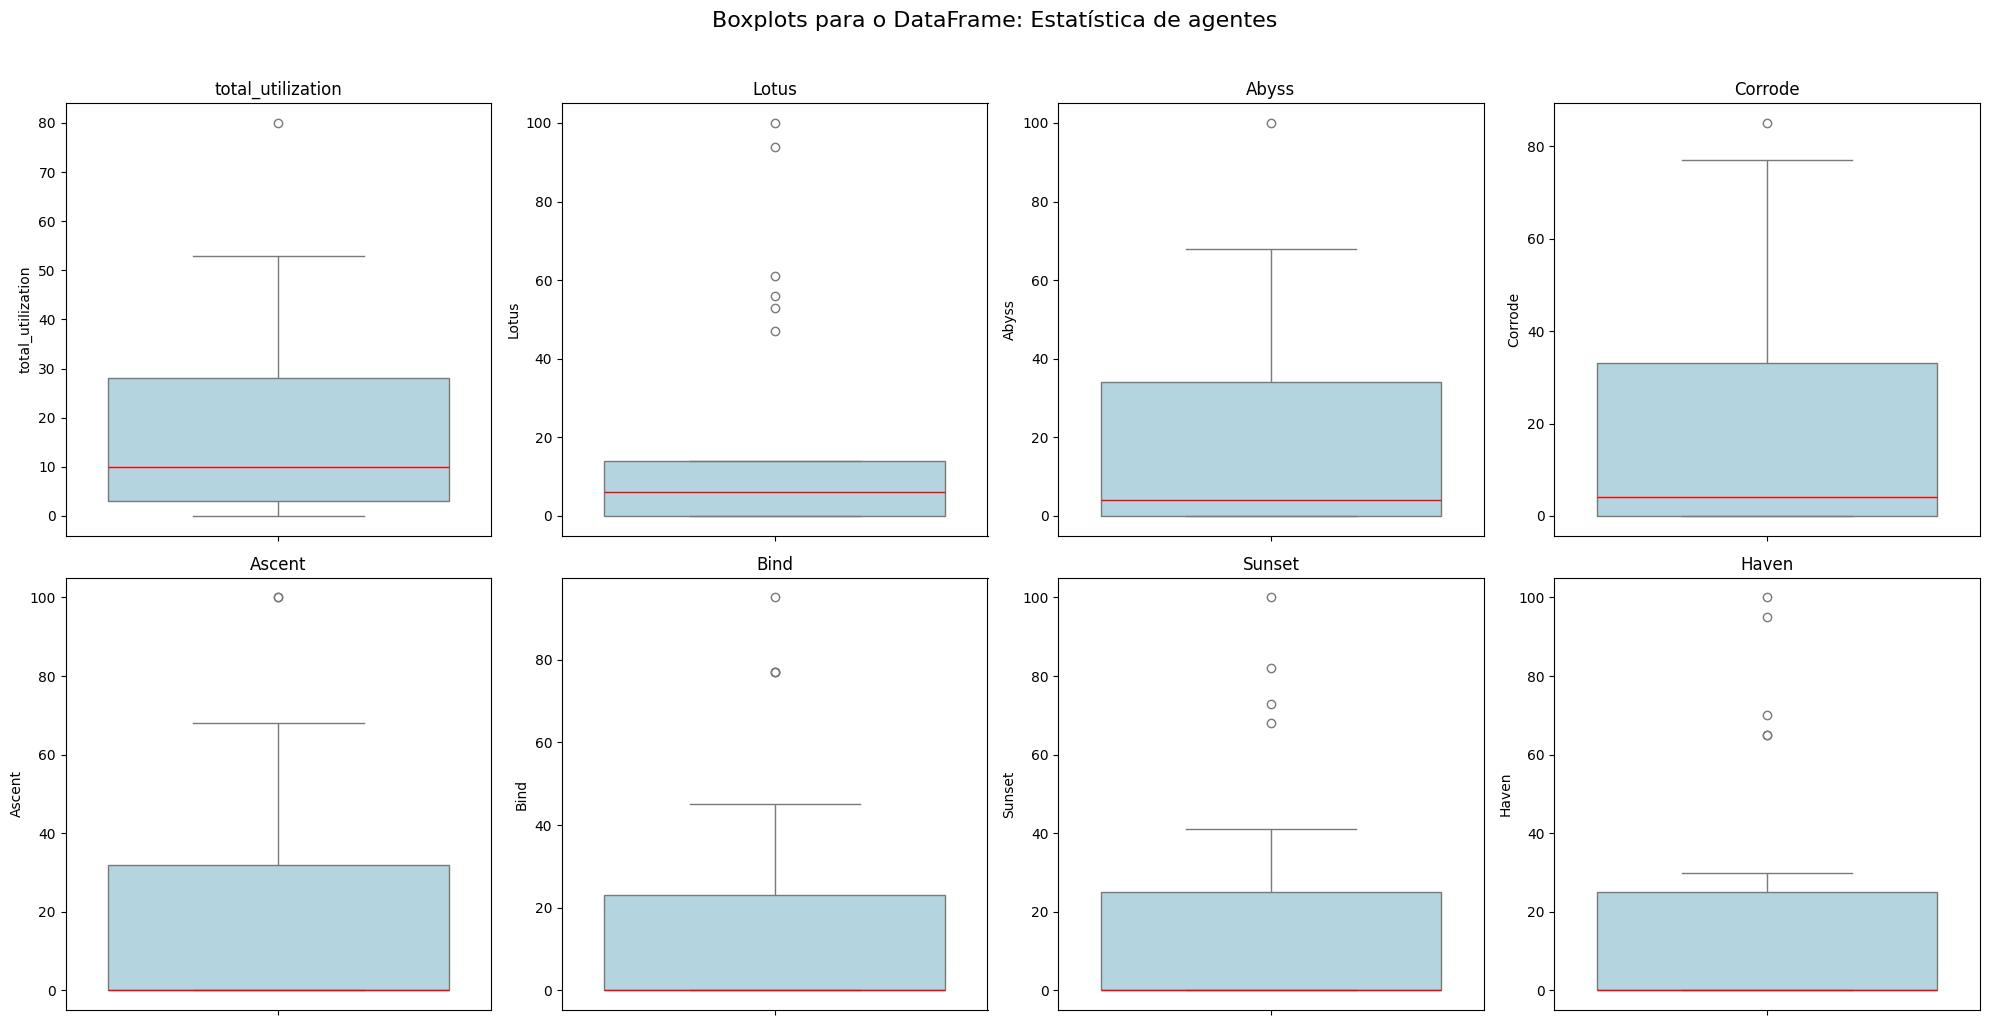

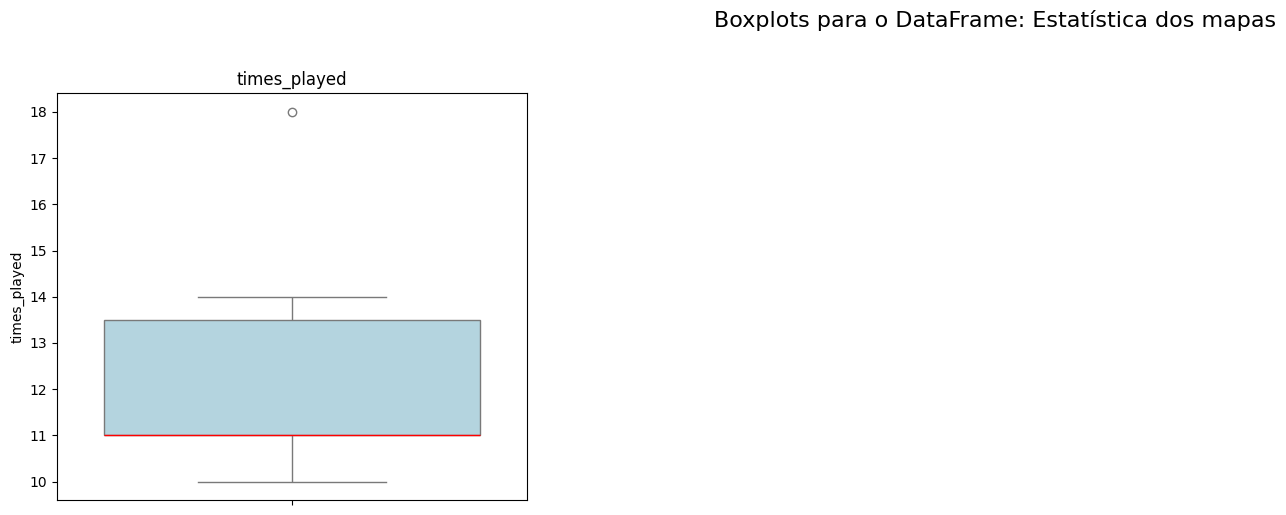

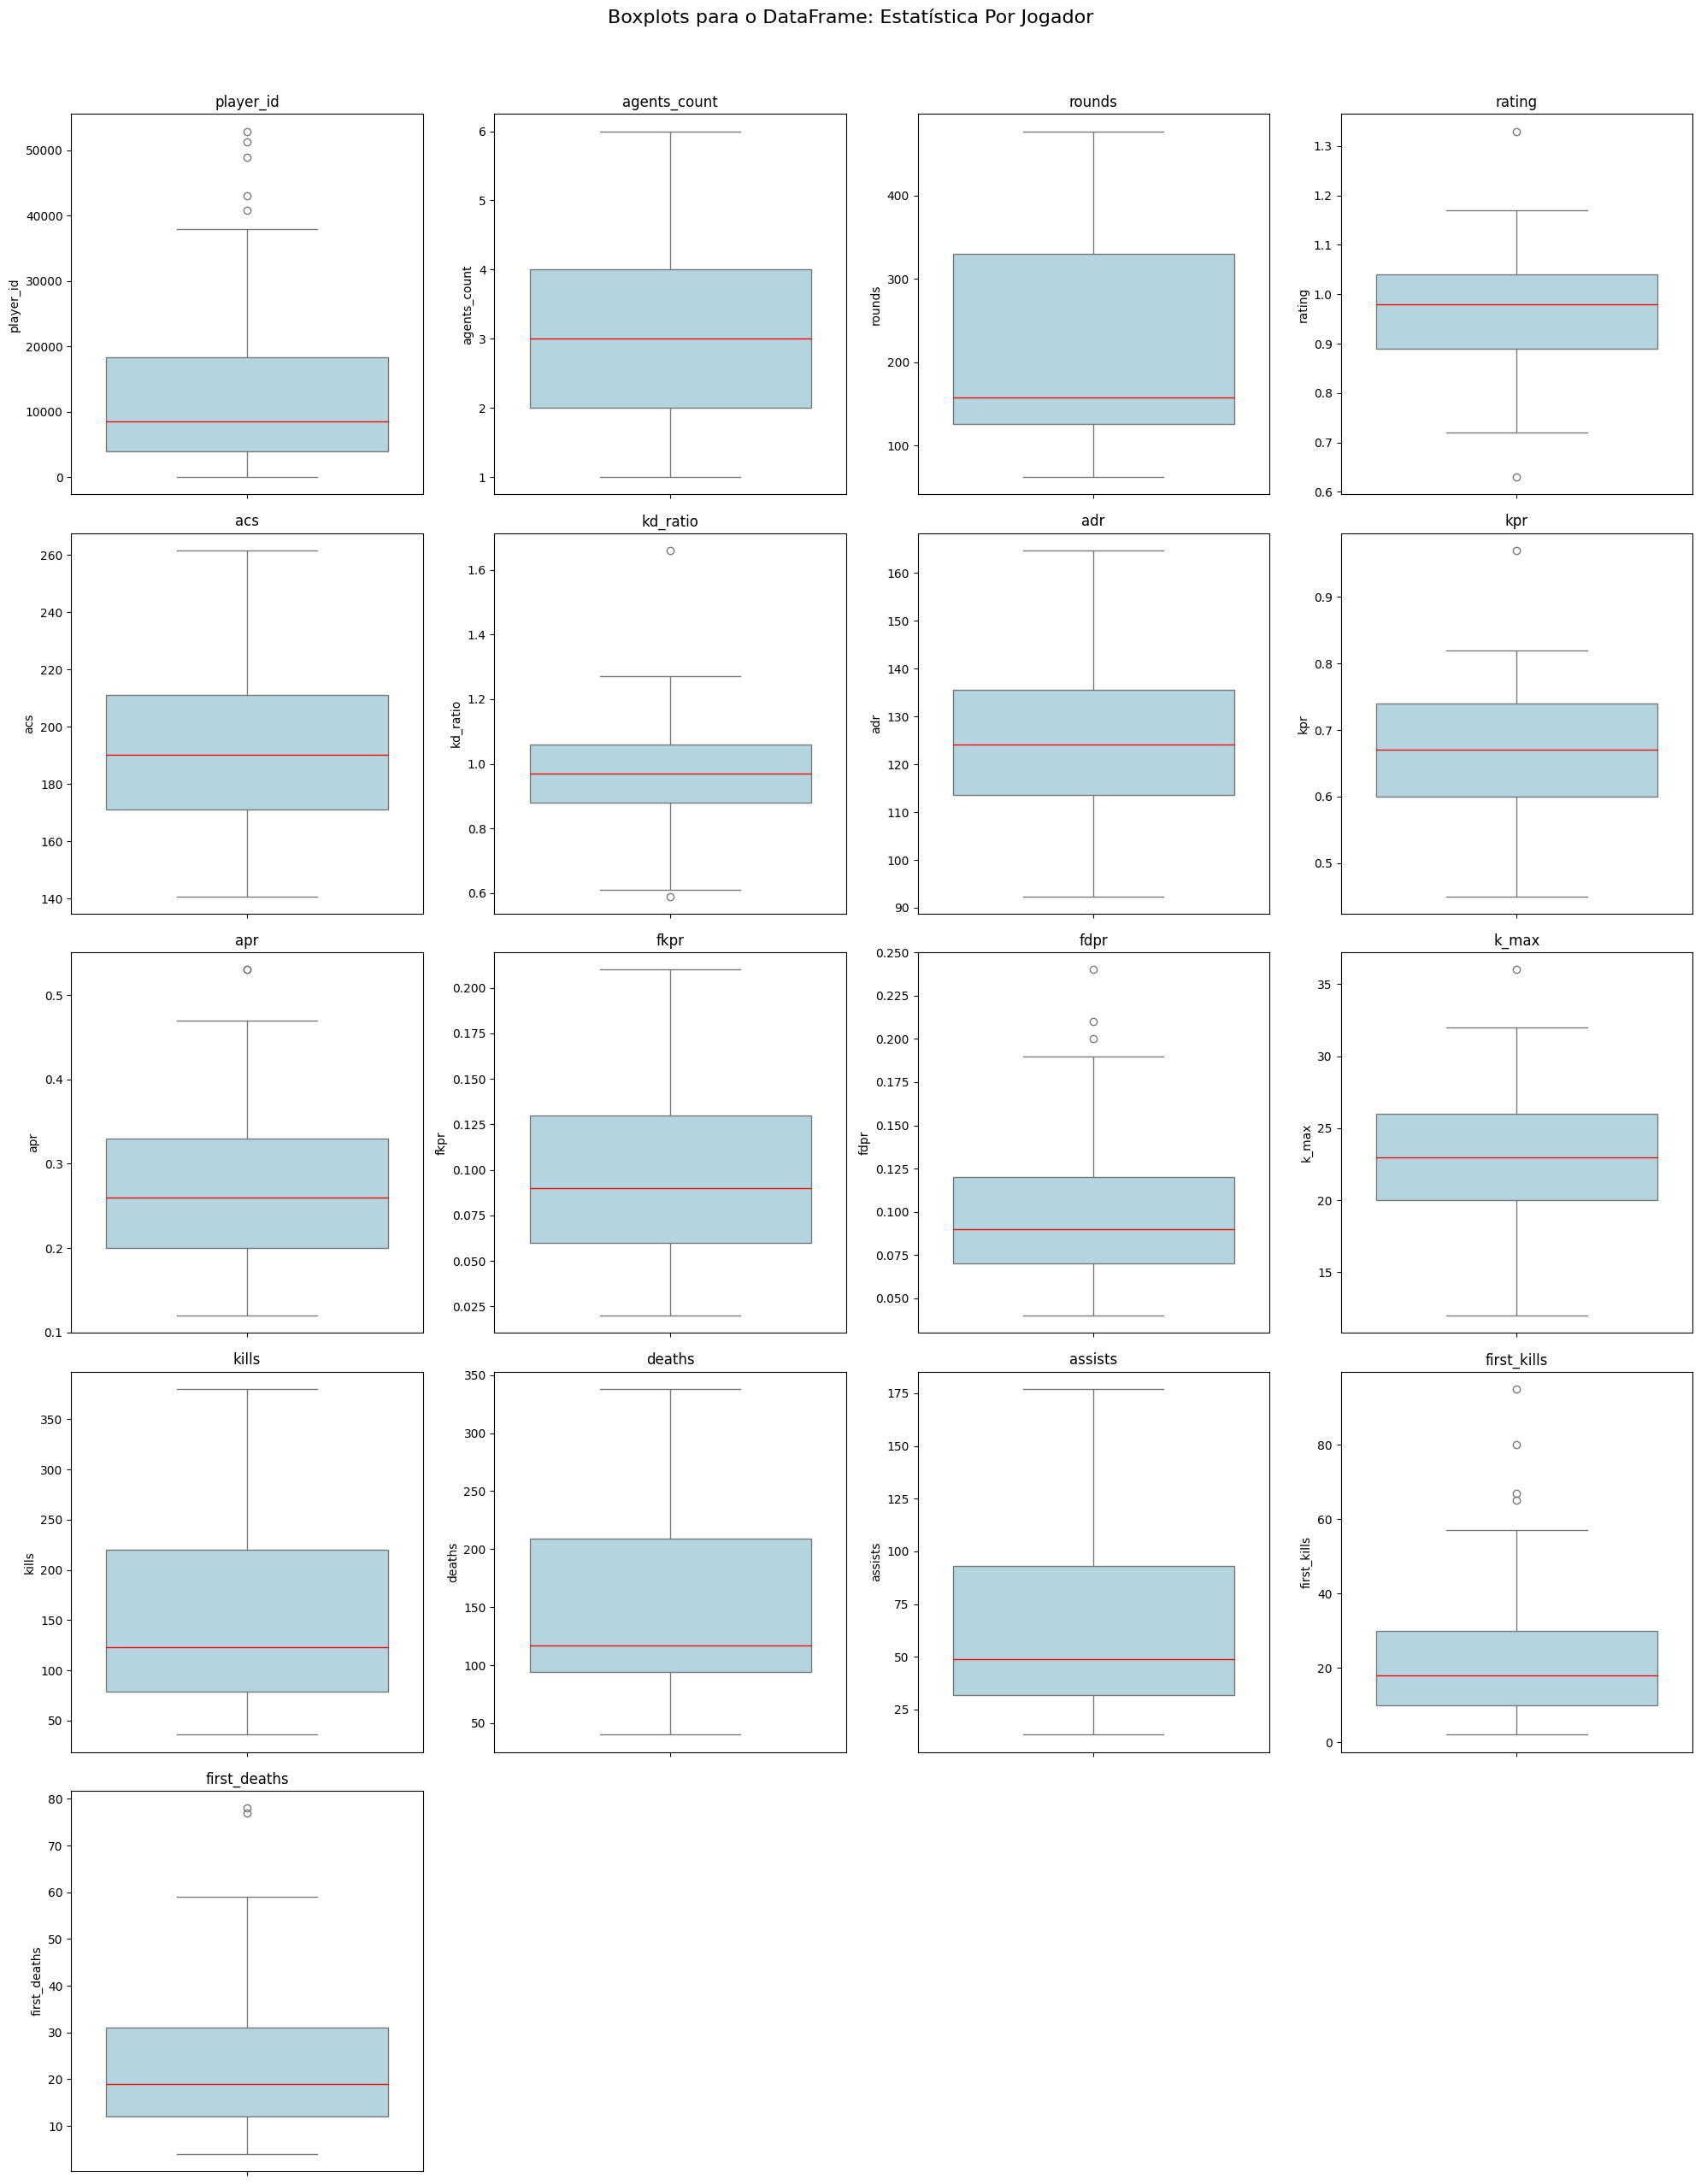

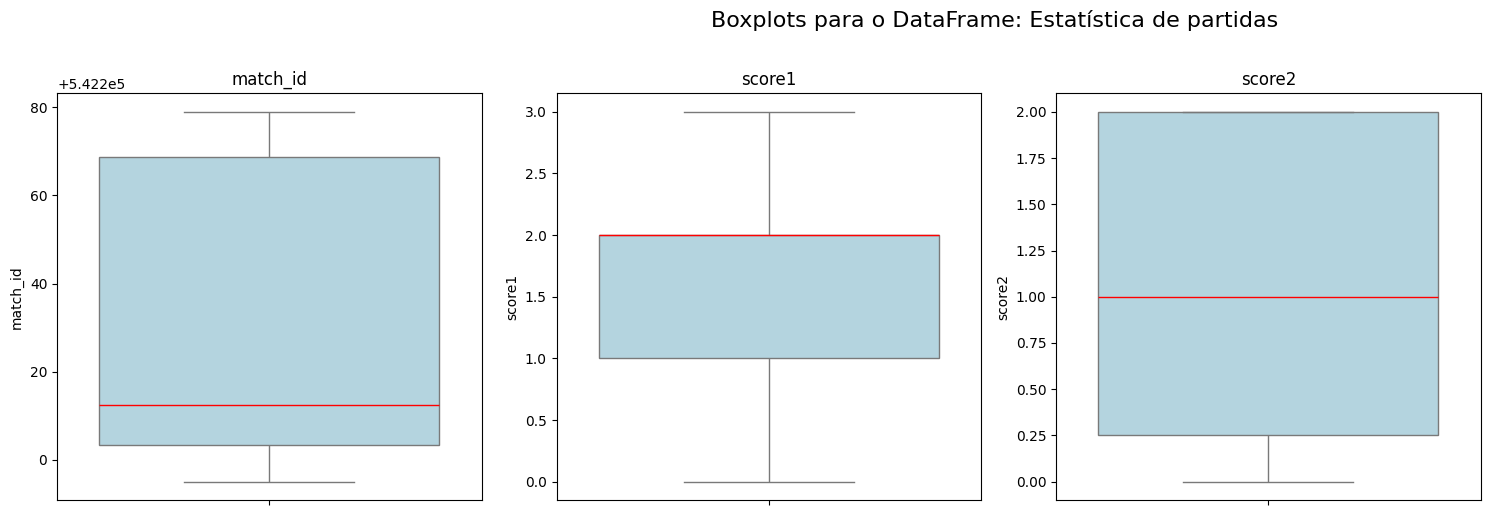

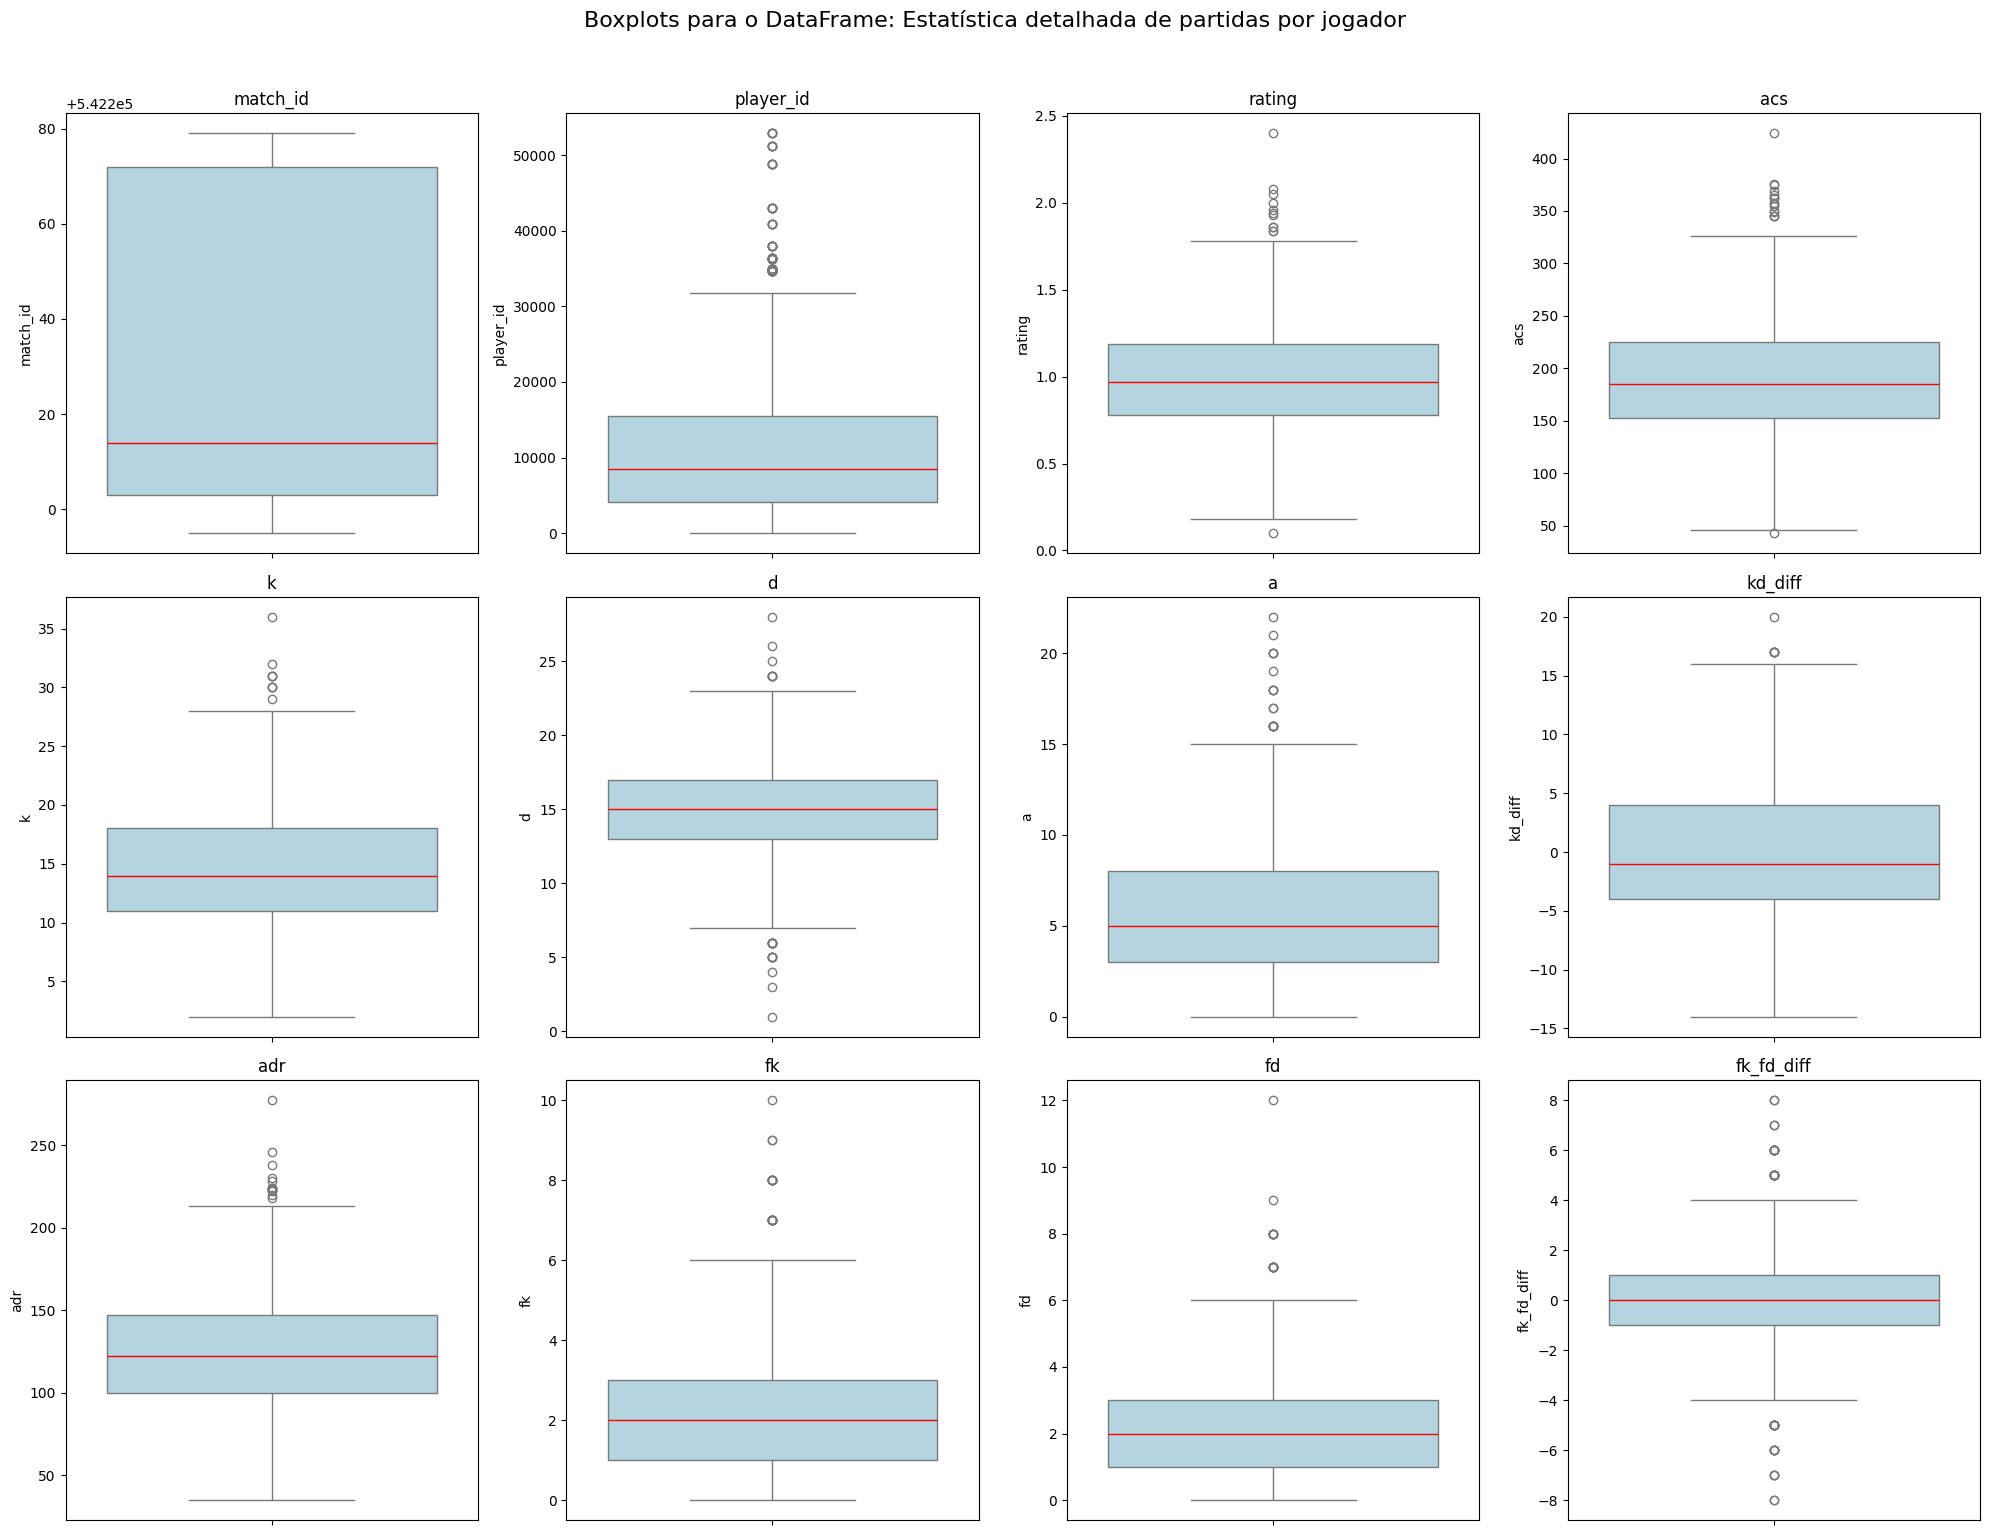

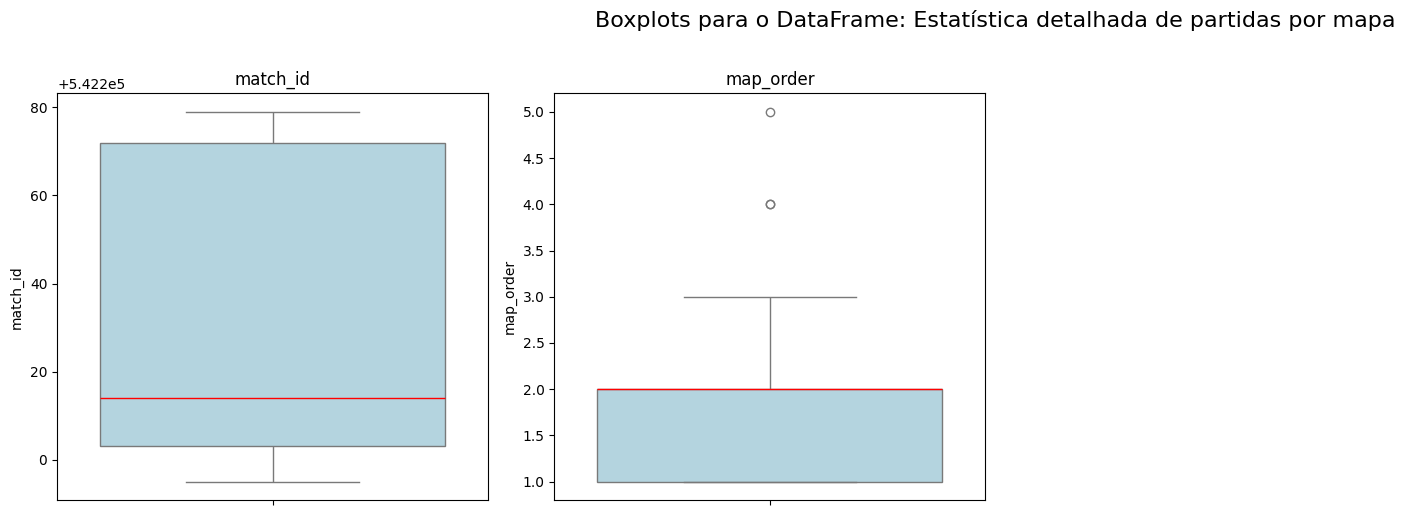

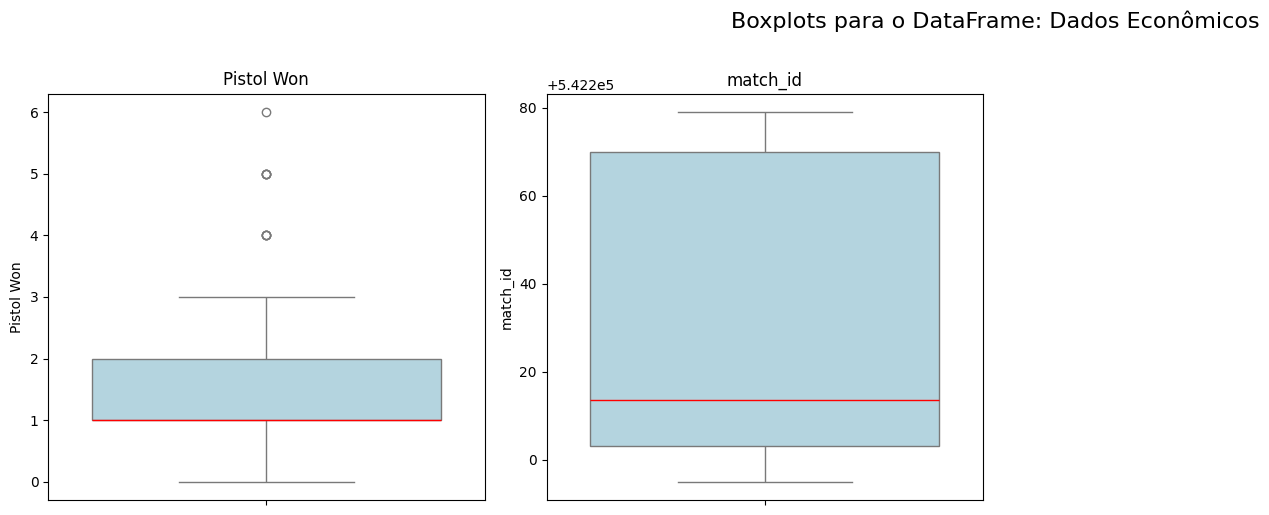

In [ ]:
numerical_cols = {}
for name, df in datasets.items():
    numerical_cols[name] = df.select_dtypes(include=np.number).columns.tolist()

for name, df in datasets.items():
    cols_to_plot = numerical_cols.get(name, [])
    num_cols = len(cols_to_plot)
    if num_cols == 0:
        print(f"Nenhuma feature númerica encontrada em: {name}.")
        continue

    # Layout da figure
    cols_per_row = 4 # Limitado a 3 figures por linha
    num_rows = int(np.ceil(num_cols / cols_per_row))

    # Cria uma nova figure para df
    fig, axs = plt.subplots(num_rows, cols_per_row, figsize=(5 * cols_per_row, 5 * num_rows))
    fig.suptitle(f'Boxplots para o DataFrame: {name}', fontsize=16, y=1.02)

    # Transforma 'axs' em um array 1D
    axs = axs.flatten()

    for i, col in enumerate(cols_to_plot):
        ax = axs[i] # Usa o i para selecionar o eixo correto

        sns.boxplot(y=df[col], ax=ax, color='lightblue', medianprops={'color':'red'})

        ax.set_title(f'{col}', fontsize=12)
        ax.set_ylabel(col)
        ax.tick_params(axis='x',labelbottom=False)

    for j in range(num_cols, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

## **Overview**

### **Relacionamentos**

In [ ]:
from plotly.graph_objs import Font
fig = px.scatter(player_stats,
                 x='rounds',
                 y='kpr',
                 labels={'rounds': 'Total de Rounds Jogados', 'kpr': 'Kills Por Round'},
                 hover_data=['player_name', 'team', 'kd_ratio']) # Adiciona informações no hover

fig.update_traces(mode='markers', marker=dict(size=8))

fig.update_layout(
    xaxis_title='Total de Rounds Jogados',
    yaxis_title='Kills Por Round',
    hovermode='closest',
    title=dict(
        text='Relação entre Rounds e KPR por Jogador',
        font=dict(
            size=22
        )
    )
)

fig.show()

### **Vitórias**






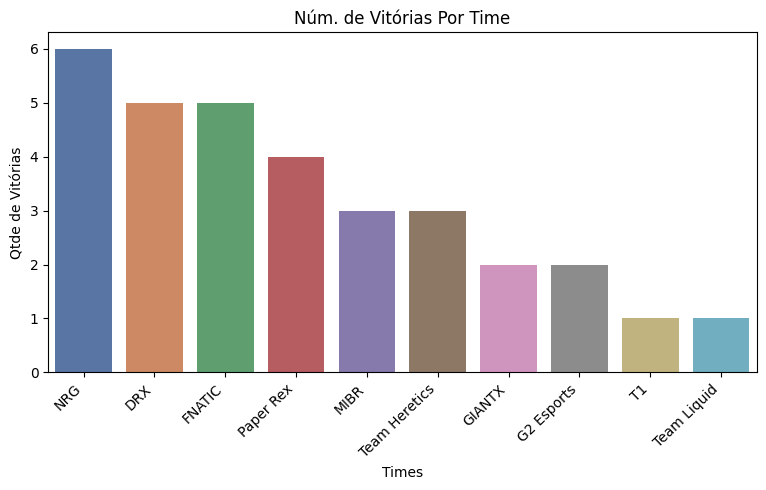

In [ ]:
qtde_vitorias = matches['winner'].value_counts().head(10)

plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 2, 1)
sns.barplot(x=qtde_vitorias.index, y=qtde_vitorias.values, palette="deep", ax = ax1)
ax1.set_title('Núm. de Vitórias Por Time')
ax1.set_xlabel('Times')
ax1.set_ylabel('Qtde de Vitórias')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=44, ha='right')

maps_stats_melted = maps_stats.melt(
    id_vars='map_name',
    value_vars=['attack_win_percent', 'defense_win_percent'],
    var_name='side',
    value_name='win_percentage'
)

plt.tight_layout()
plt.show()


### **Performance dos jogadores**

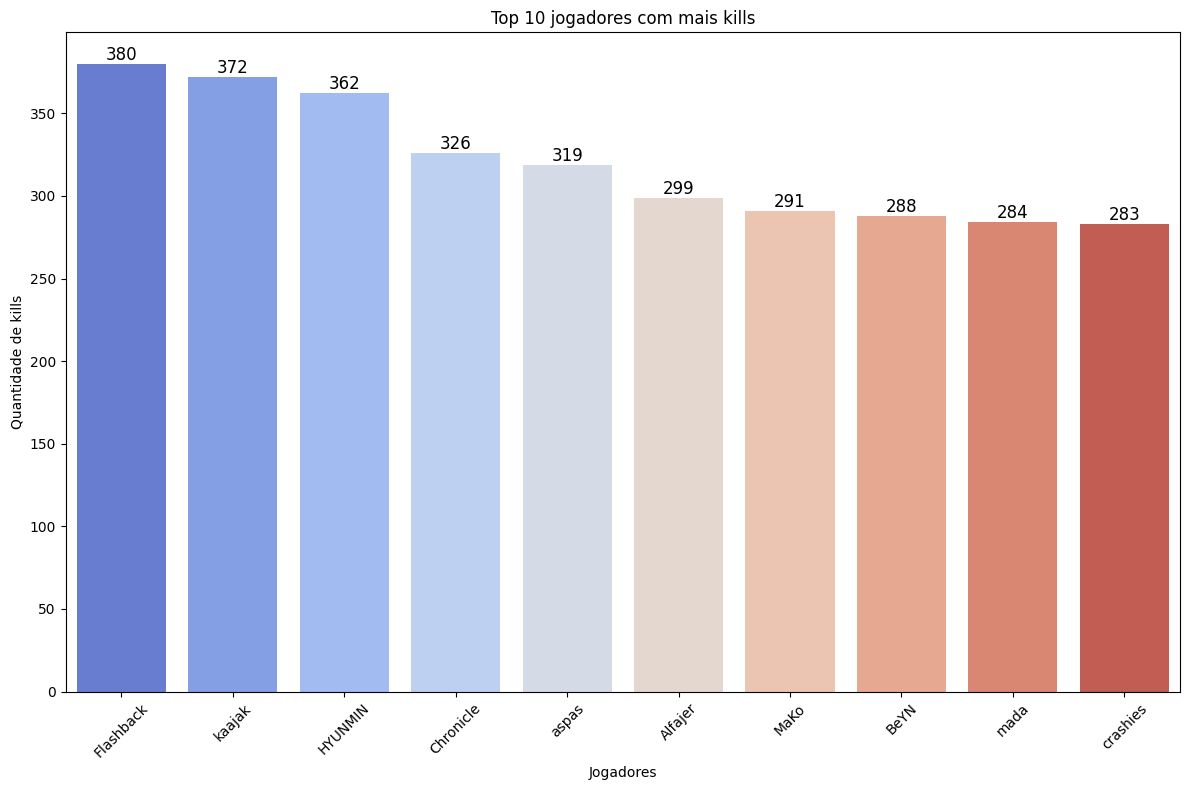

In [ ]:
# Most Kills
most_kills = player_stats.sort_values('kills', ascending=False).head(10)
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='player_name', y='kills', data=most_kills, palette='coolwarm')

# Mostra o num total de kills feitas em cima de cada barra
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2.,
        p.get_height(),
        f'{int(p.get_height())}',
        ha='center',
        va='bottom',
        fontsize=12,
        color='black'
    )

plt.title('Top 10 jogadores com mais kills')
plt.xlabel('Jogadores')
plt.ylabel('Quantidade de kills')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


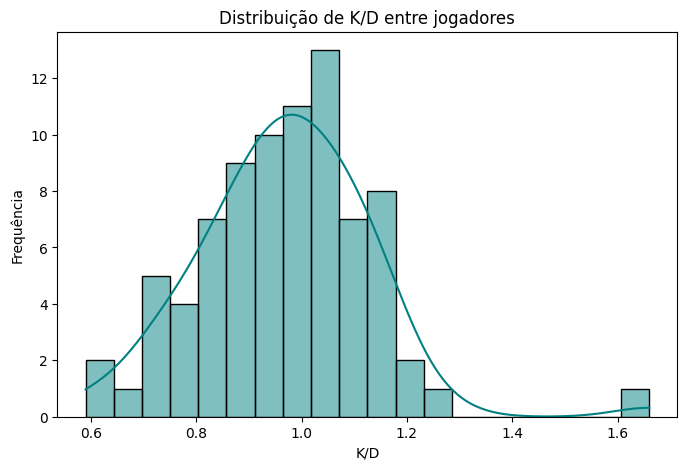

In [ ]:
# Distribuição K/D
plt.figure(figsize=(8, 5))
sns.histplot(player_stats['kd_ratio'], bins=20, kde=True, color='teal')
plt.title('Distribuição de K/D entre jogadores')
plt.xlabel('K/D')
plt.ylabel('Frequência')
plt.show()

### **Agentes**

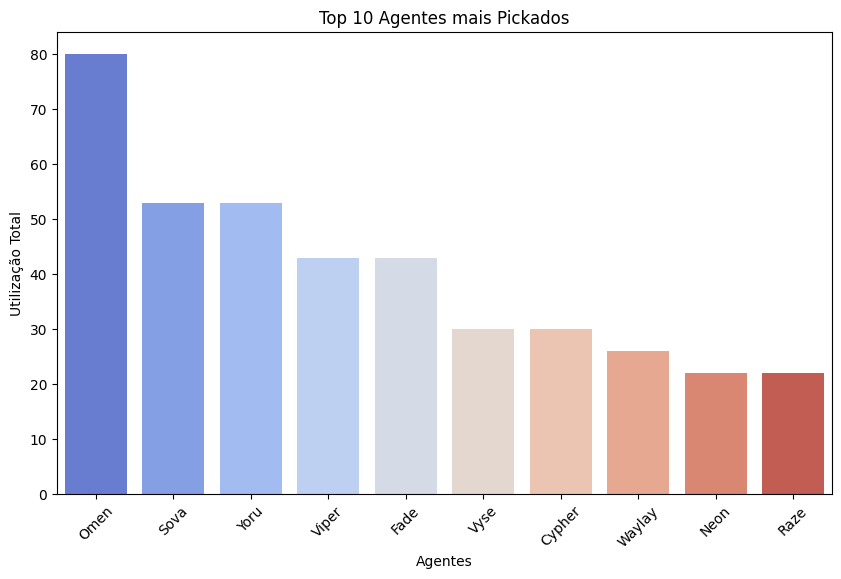

In [ ]:
# Agentes mais pickados
top_agents = agents_stats.sort_values('total_utilization', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x='agent_name', y='total_utilization', data=top_agents, palette='coolwarm')
plt.title('Top 10 Agentes mais Pickados')
plt.xlabel('Agentes')
plt.ylabel('Utilização Total')
plt.xticks(rotation=45)
plt.show()